In this notebook, we will perform a thorough analysis on BC wildfire from 2023-2025, with a focus on Prince George Fire Region.

In [1]:
import os

os.chdir('/Users/bill/Documents/Co-op/wps-research/data/bill')

In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd

In [3]:
pd.set_option("display.max_colwidth", 30)

In [4]:
gdf = gpd.read_file("C11659/IN_HISTORICAL_FIRE_POLYGONS_SVW/IN_HISTORICAL_FIRE_POLYGONS_SVW.shp")

gdf.head(3)

,FIRE_YEAR,FIRE_NUMBE,VERSION_NU,FIRE_SIZE_,SOURCE,GPS_TRACK_,LOAD_DATE,FIRE_DATE,CREATION_M,CAUSE_SPEC,CAUSE_GENE,FIRE_KEY,USERID,WFNProject,WFNDisplay,WAS_FIRE_O,geometry
0,2023,C10112,2023042901,2.1,2023 ROLLOVER,2023-04-29,2023-05-31,2023-04-28,Non-corrected ground GPS,Other Industry,Human,2023-C10112,CPENOLIO,0,NaN,N,POLYGON ((1100420.216 8988...
1,2023,C10382,2023052002,74.3,2023 ROLLOVER,2023-05-20,2023-06-02,2023-05-18,Non-corrected airborne GPS,Lightning,Natural,2023-C10382,CDALY,0,NaN,N,POLYGON ((1278095.912 9050...
2,2023,C10395,2023051901,19.0,2023 ROLLOVER,2023-05-19,2023-05-23,2023-05-17,Non-corrected ground GPS,Lightning,Natural,2023-C10395,CPENOLIO,0,NaN,N,POLYGON ((1291138.703 9298...


We only need some important attributes

In [5]:
gdf = gdf[['FIRE_YEAR', 'FIRE_NUMBE', 'FIRE_SIZE_', 'FIRE_DATE', 'CAUSE_GENE', 'geometry']]

gdf.head()

,FIRE_YEAR,FIRE_NUMBE,FIRE_SIZE_,FIRE_DATE,CAUSE_GENE,geometry
0,2023,C10112,2.1,2023-04-28,Human,POLYGON ((1100420.216 8988...
1,2023,C10382,74.3,2023-05-18,Natural,POLYGON ((1278095.912 9050...
2,2023,C10395,19.0,2023-05-17,Natural,POLYGON ((1291138.703 9298...
3,2023,C10431,75.0,2023-05-20,Natural,POLYGON ((1201707.794 8507...
4,2023,C10439,1.2,2023-05-20,Natural,POLYGON ((1174241.75 90926...


**Questions we want to know about BC in general**

1. Which years BC burned the most, how large they were?

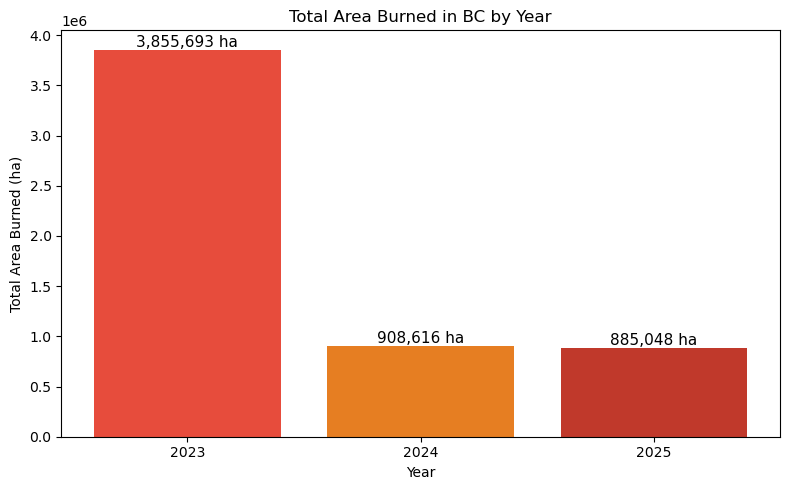

In [6]:
import matplotlib.pyplot as plt

yearly = gdf.groupby("FIRE_YEAR")["FIRE_SIZE_"].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(yearly["FIRE_YEAR"], yearly["FIRE_SIZE_"], color=["#e74c3c", "#e67e22", "#c0392b"])
ax.set_xlabel("Year")
ax.set_ylabel("Total Area Burned (ha)")
ax.set_title("Total Area Burned in BC by Year")

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f} ha",
        ha="center", va="bottom", fontsize=11
    )
    
plt.tight_layout()
plt.show()

2. Which fire regions were impacted the most each year? 

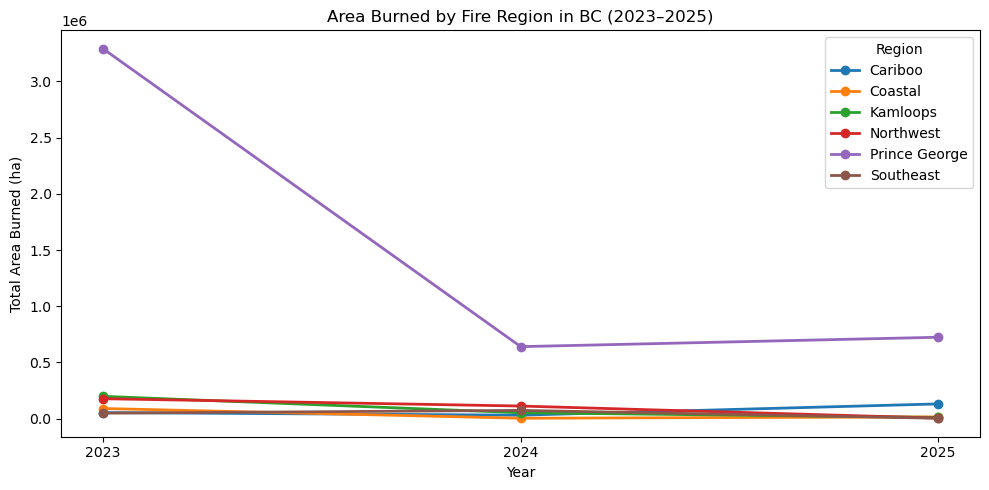

In [7]:
# Extract region (first letter)
gdf["REGION"] = gdf["FIRE_NUMBE"].str[0]

# Map to full names
region_names = {
    "C": "Cariboo",
    "V": "Coastal",
    "K": "Kamloops",
    "R": "Northwest",
    "G": "Prince George",
    "N": "Southeast"
}
gdf["REGION_NAME"] = gdf["REGION"].map(region_names)

# Group by year and region
regional = gdf.groupby(["FIRE_YEAR", "REGION_NAME"])["FIRE_SIZE_"].sum().reset_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

for region, data in regional.groupby("REGION_NAME"):
    ax.plot(data["FIRE_YEAR"], data["FIRE_SIZE_"], marker="o", label=region, linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Total Area Burned (ha)")
ax.set_title("Area Burned by Fire Region in BC (2023–2025)")
ax.legend(title="Region")
plt.tight_layout()
plt.show()

**Within PGFC**

We will be inspecting the fire zones within Prince George Fire Centre. 

In [8]:
# Filter Prince George and extract zone
pg = gdf[gdf["REGION_NAME"] == "Prince George"].copy()
pg["ZONE"] = pg["FIRE_NUMBE"].str[1]  # single digit after G
pg["ZONE"] = "G" + pg["ZONE"]  # label as G1, G2, etc.

pg["ZONE"].value_counts()  # see which zones exist

ZONE
G9    113
G8     95
G7     72
G1     53
G4     43
G5     43
G6     39
G3     32
Name: count, dtype: int64

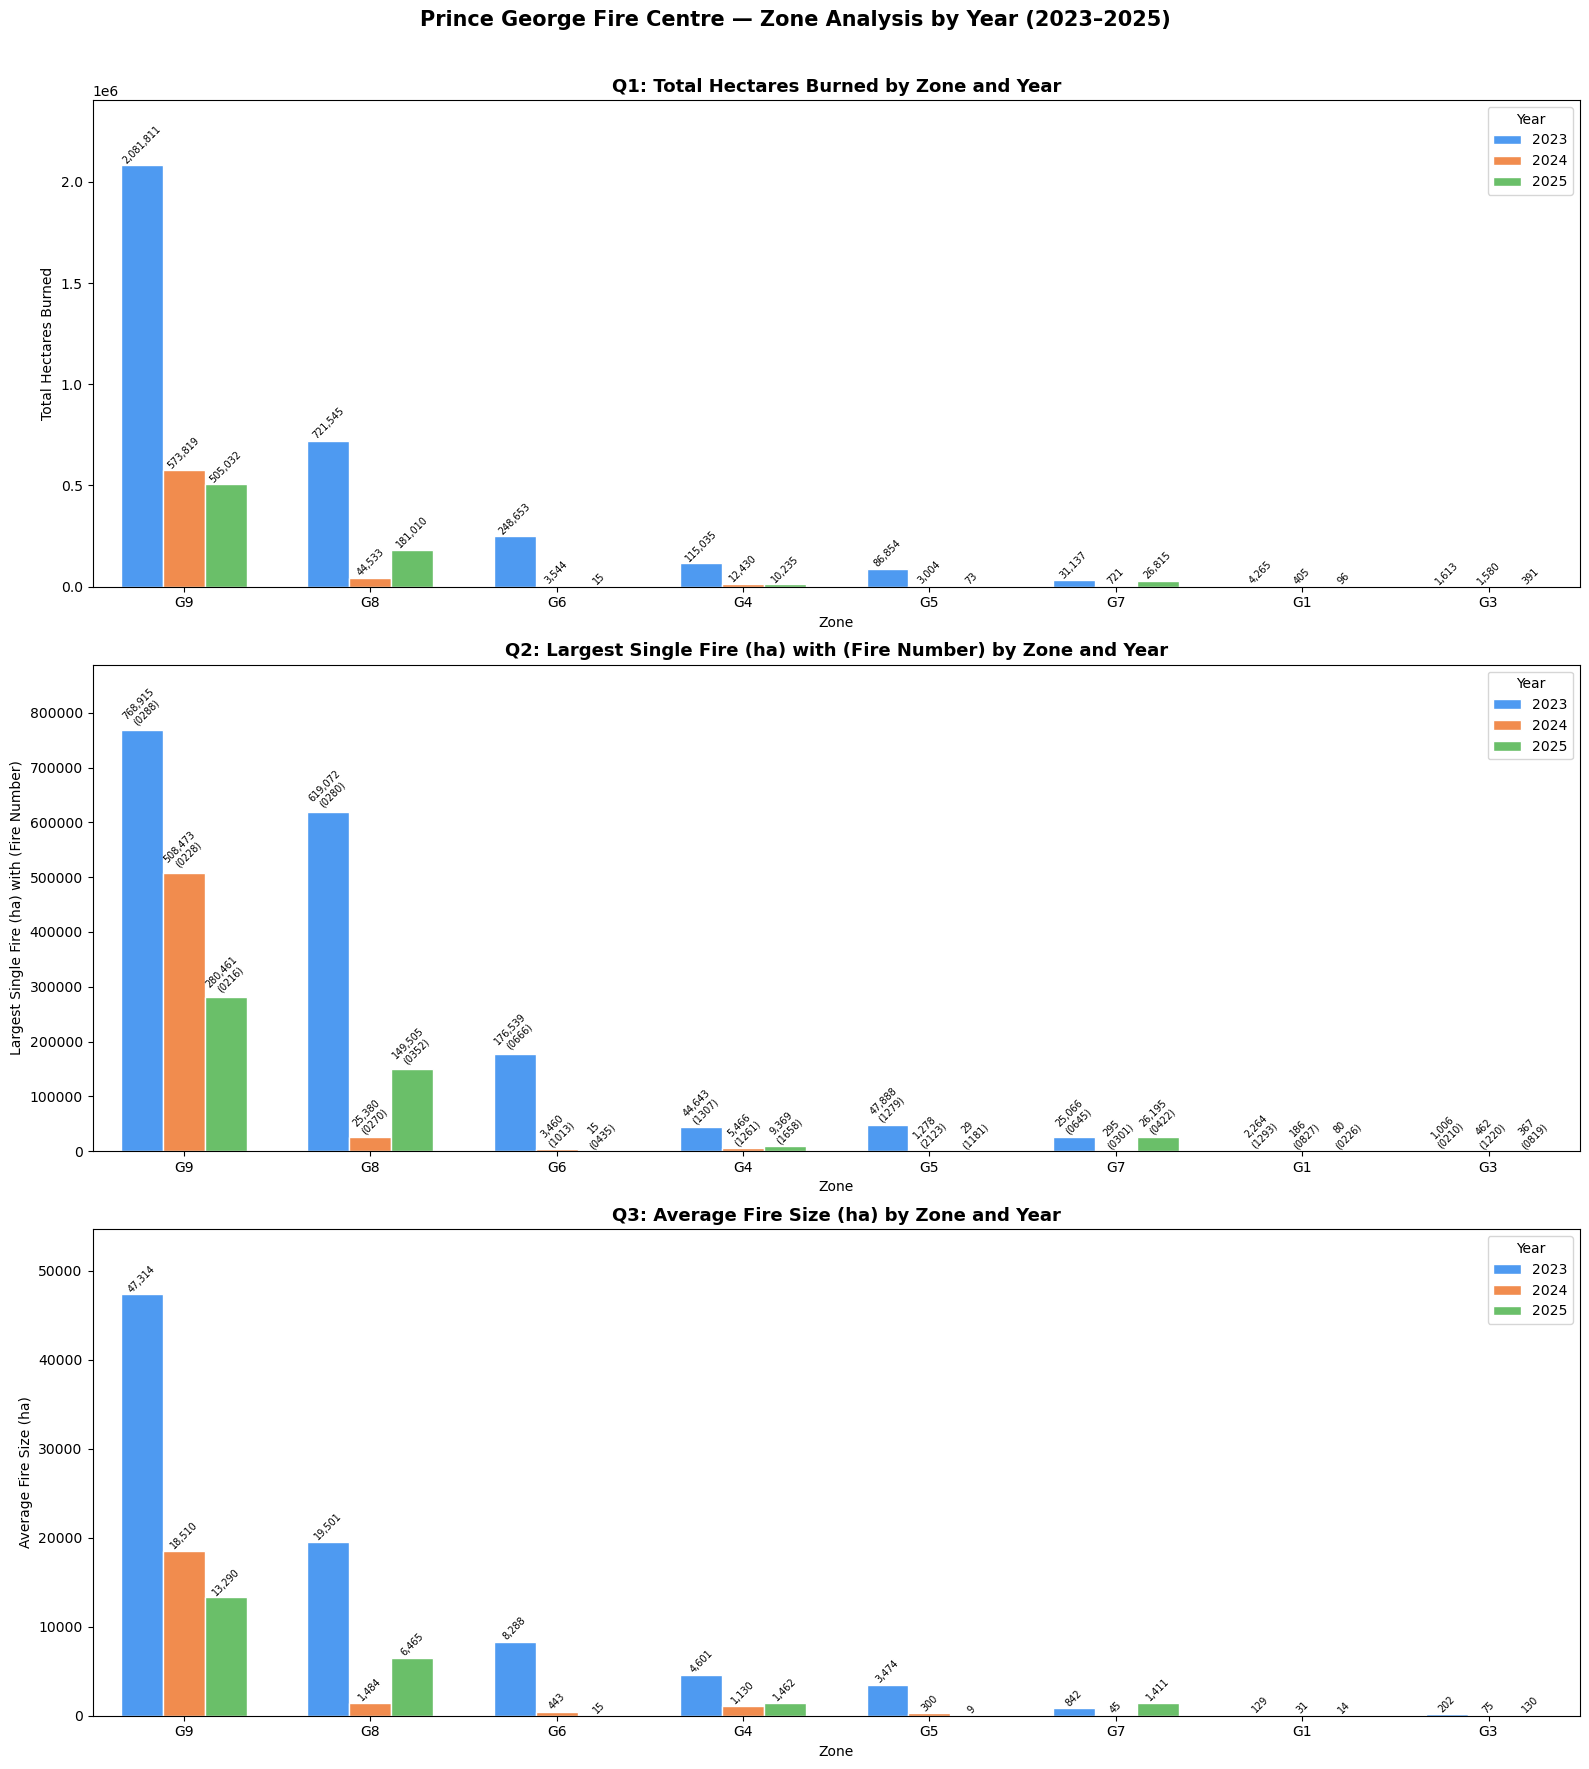

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

pg = gdf[gdf["REGION_NAME"] == "Prince George"].copy()
pg["ZONE"] = "G" + pg["FIRE_NUMBE"].str[1]

metrics = [
    ("sum",  "Total Hectares Burned",    "Q1", "YlOrRd"),
    ("max",  "Largest Single Fire (ha) with (Fire Number)", "Q2", "OrRd"),
    ("mean", "Average Fire Size (ha)",   "Q3", "PuRd"),
]

years = sorted(pg["FIRE_YEAR"].unique())
year_colors = {"2023": "#4e9af1", "2024": "#f18c4e", "2025": "#6abf69"}

# Order zones by total burned area descending
zone_total = pg.groupby("ZONE")["FIRE_SIZE_"].sum().sort_values(ascending=False)
zones = zone_total.index.tolist()

# Get fire number of largest fire per zone/year (for Q2)
max_fire = pg.loc[pg.groupby(["ZONE", "FIRE_YEAR"])["FIRE_SIZE_"].idxmax()][["ZONE", "FIRE_YEAR", "FIRE_SIZE_", "FIRE_NUMBE"]]

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for row, (agg_func, label, q, cmap) in enumerate(metrics):
    ax = axes[row]

    zone_year = pg.groupby(["ZONE", "FIRE_YEAR"])["FIRE_SIZE_"].agg(agg_func).reset_index()

    x = np.arange(len(zones)) * 0.8
    width = 0.18

    for i, year in enumerate(years):
        df_year = zone_year[zone_year["FIRE_YEAR"] == year].set_index("ZONE")["FIRE_SIZE_"].reindex(zones, fill_value=0)
        bars = ax.bar(x + i * width, df_year.values, width=width,
                      label=str(year), color=year_colors[year], edgecolor="white")

        for j, (bar, zone) in enumerate(zip(bars, zones)):
            h = bar.get_height()
            if h > 0:
                if q == "Q2":
                    fire_row = max_fire[(max_fire["ZONE"] == zone) & (max_fire["FIRE_YEAR"] == year)]
                    if not fire_row.empty:
                        fire_num = f'({fire_row["FIRE_NUMBE"].values[0][-4:]})'
                        ax.text(bar.get_x() + bar.get_width()/2, h,
                                f"{h:,.0f}\n{fire_num}", ha="center", va="bottom", fontsize=7, rotation=45)
                else:
                    ax.text(bar.get_x() + bar.get_width()/2, h,
                            f"{h:,.0f}", ha="center", va="bottom", fontsize=7, rotation=45)

    ax.set_title(f"{q}: {label} by Zone and Year", fontsize=13, fontweight="bold")
    ax.set_xlabel("Zone")
    ax.set_ylabel(label)
    ax.set_xticks(x + width)
    ax.set_xticklabels(zones)
    ax.legend(title="Year")
    ax.margins(x=0.02)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.suptitle("Prince George Fire Centre — Zone Analysis by Year (2023–2025)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()